Nama : Muhammad Ghofara Revonanda \\
NPM  : 2106722461

In [ ]:
pip install kagglehub scikit-learn opencv-python numpy

In [ ]:
import kagglehub
import os

# Unduh dataset dari Kaggle
print("Mengunduh dataset dari Kaggle...")
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

# Path ke folder data sebenarnya
dataset_dir = os.path.join(
    path,
    "New Plant Diseases Dataset(Augmented)",
    "New Plant Diseases Dataset(Augmented)",
    "train"
)

print("Dataset disimpan di:", dataset_dir)

Mengunduh dataset dari Kaggle...
Dataset disimpan di: /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train


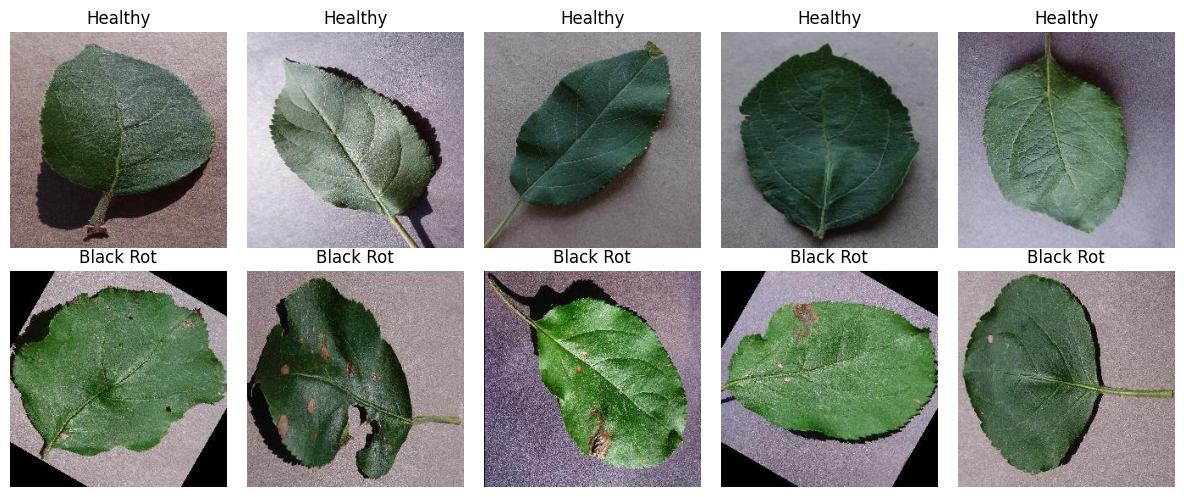

In [ ]:
import os
import matplotlib.pyplot as plt
import cv2

# Nama folder untuk healthy dan black rot
healthy_folder = os.path.join(dataset_dir, 'Apple___healthy')
blackrot_folder = os.path.join(dataset_dir, 'Apple___Black_rot')

# Ambil 5 gambar dari masing-masing kelas
healthy_images = [os.path.join(healthy_folder, f) for f in os.listdir(healthy_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:5]
blackrot_images = [os.path.join(blackrot_folder, f) for f in os.listdir(blackrot_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:5]

# Visualisasi
plt.figure(figsize=(12, 5))

# Tampilkan gambar Healthy
for i, img_path in enumerate(healthy_images):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title("Healthy")
    plt.axis('off')

# Tampilkan gambar Black Rot
for i, img_path in enumerate(blackrot_images):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(2, 5, i + 6)
    plt.imshow(img)
    plt.title("Black Rot")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import os
import cv2
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from skimage.feature import local_binary_pattern

# Pastikan variabel `dataset_dir` sudah tersedia dari cell sebelumnya
classes = {
    'Apple___Black_rot': 1,    # daun sakit
    'Apple___healthy': 0       # daun sehat
}

def extract_features(image_path):
    # Baca gambar
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Gagal membaca gambar: {image_path}")

    # Ubah ukuran gambar
    image = cv2.resize(image, (100, 100))

    # Konversi gambar ke HSV
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Fitur warna: Mean dan Standard Deviation untuk H, S, V
    mean = np.mean(hsv, axis=(0, 1))
    std = np.std(hsv, axis=(0, 1))

    # Fitur tekstur: Local Binary Pattern (LBP)
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    lbp = local_binary_pattern(gray_image, P=8, R=1, method='uniform')
    lbp_histogram, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 11), range=(0, 10))
    lbp_histogram = lbp_histogram / lbp_histogram.sum()  # Normalisasi histogram

    # Gabungkan semua fitur
    features = np.concatenate([mean, std, lbp_histogram])

    return features

features = []
labels = []

print("Mengekstrak fitur dari gambar...")
for class_name, label in classes.items():
    folder_path = os.path.join(dataset_dir, class_name)
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            try:
                feat = extract_features(file_path)
                features.append(feat)
                labels.append(label)
            except Exception as e:
                print(f"[SKIP] {filename} error: {e}")

# Siapkan data
X = np.array(features)
y = np.array(labels)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model SVM
print("Melatih model SVM...")
model = SVC(kernel='rbf', C=1.0, gamma='scale')
model.fit(X_train, y_train)

# Evaluasi
y_pred = model.predict(X_test)
print("Program selesai")

Mengekstrak fitur dari gambar...
Melatih model SVM...
Program selesai


In [ ]:
import numpy as np

print("Total data yang digunakan:", len(labels))
print("  - Data sehat     :", np.sum(y == 0))
print("  - Data penyakit  :", np.sum(y == 1))

Total data yang digunakan: 3995
  - Data sehat     : 2008
  - Data penyakit  : 1987


In [ ]:
import pandas as pd

# Gabungkan fitur dan label ke dalam DataFrame
df_features = pd.DataFrame(X, columns=[f'Feature_{i+1}' for i in range(X.shape[1])])
df_features['Label'] = y  # Menambahkan label ke DataFrame

# Pisahkan berdasarkan label (0 = Healthy, 1 = Black Rot)
df_healthy_features = df_features[df_features['Label'] == 0].drop('Label', axis=1)
df_sick_features = df_features[df_features['Label'] == 1].drop('Label', axis=1)

# Tampilkan beberapa baris pertama untuk perbandingan
print("Fitur Daun Sehat:")
print(df_healthy_features.head())

print("\nFitur Daun Sakit:")
print(df_sick_features.head())

# Tambahkan visualisasi perbandingan jumlah fitur
print("\nJumlah data sehat:", len(df_healthy_features))
print("Jumlah data sakit:", len(df_sick_features))

Fitur Daun Sehat:
      Feature_1  Feature_2  Feature_3  Feature_4  Feature_5  Feature_6  \
1987    41.9745    56.0308   112.0994  50.452045  36.160446  47.649371   
1988   105.9232    28.8314   160.1269  43.282476  24.024445  48.478573   
1989   100.8912    45.2323   103.2974  58.932963  41.506411  34.674428   
1990    92.3081    64.2188    92.8547  30.500354  50.430893  42.807621   
1991   101.7292    47.8536   134.0046  35.575701  24.901015  38.398791   

      Feature_7  Feature_8  Feature_9  Feature_10  Feature_11  Feature_12  \
1987     0.1358     0.1095     0.0524      0.0485      0.0528      0.0576   
1988     0.1356     0.1030     0.0555      0.0558      0.0582      0.0699   
1989     0.1248     0.0955     0.0569      0.0591      0.0836      0.0743   
1990     0.0982     0.1019     0.0500      0.0719      0.1040      0.0890   
1991     0.1297     0.1042     0.0586      0.0567      0.0610      0.0662   

      Feature_13  Feature_14  Feature_15  Feature_16  
1987      0.0505   

In [ ]:
print("Jumlah data latih (train):", len(X_train))
print("Jumlah data uji   (test) :", len(X_test))

Jumlah data latih (train): 3196
Jumlah data uji   (test) : 799


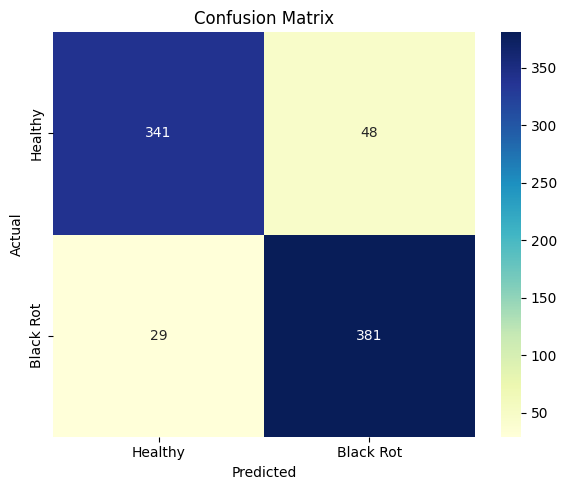

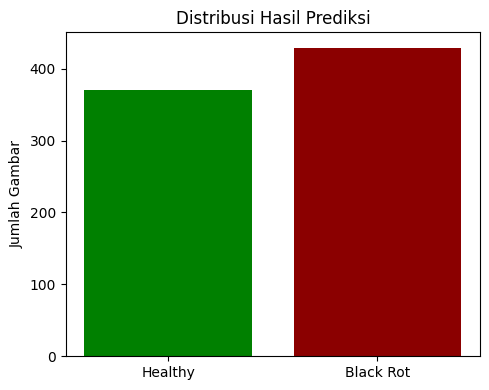

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
labels = ["Healthy", "Black Rot"]

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu", xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Distribusi Hasil Prediksi
unique, counts = np.unique(y_pred, return_counts=True)
plt.figure(figsize=(5, 4))
plt.bar([labels[i] for i in unique], counts, color=['green', 'darkred'])
plt.title("Distribusi Hasil Prediksi")
plt.ylabel("Jumlah Gambar")
plt.tight_layout()
plt.show()

In [ ]:
print("Evaluasi model:")
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["Healthy", "Black Rot"]))

Evaluasi model:
              precision    recall  f1-score   support

     Healthy       0.92      0.88      0.90       389
   Black Rot       0.89      0.93      0.91       410

    accuracy                           0.90       799
   macro avg       0.90      0.90      0.90       799
weighted avg       0.90      0.90      0.90       799

